# TESS Transit Analysis of TIC 25155310 b

This project demonstrates the analysis of a transiting exoplanet using
photometric data from NASA's Transiting Exoplanet Survey Satellite (TESS).

The light curve of TIC 25155310 b (WASP-126 b) is analyzed to determine
the orbital period and transit parameters. The transit is modeled using
the `batman` package, while an MCMC analysis, done using the `emcee` package, is used to estimate the
posterior distributions and uncertainties of the fitted parameters.

TESS SPOC light curves with a cadence of 120 seconds were retrieved for the target exoplanet TIC 25155310 using Lightkurve. All available 120-second observations were selected to provide a consistent cadence across the dataset.

In [1]:
import lightkurve as lk
import matplotlib.pyplot as plt
import numpy as np

from astropy.timeseries import BoxLeastSquares
from scipy.optimize import curve_fit

import batman
import emcee
import corner

plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'

%matplotlib inline

C:\Users\Benjamin\AppData\Roaming\Python\Python39\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [2]:
# Target: WASP-126 b
target = "TIC 25155310"

# Searching for TESS light curves from the SPOC pipeline
search = lk.search_lightcurve(
    target,
    mission="TESS",
    author="SPOC"
)

# Keeping only 120-second cadence observations
search_120 = search[search.table["exptime"] == 120]

# Downloading all available sectors
lc_collection = search_120.download_all()

# Stitching the individual sectors into one light curve
lc = lc_collection.stitch()

In [3]:
# Removing data points with missing values

lc_clean = lc.remove_nans()

print(f"Original data points: {len(lc)}")
print(f"After removing NaNs: {len(lc_clean)}")

Original data points: 787969
After removing NaNs: 680185


<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Normalized Flux'>

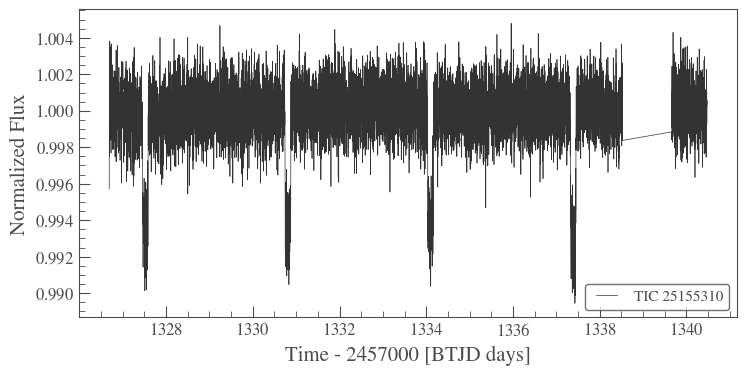

In [4]:
# Looking at a section of transit data

lc_clean[1000:10000].plot()

In [5]:
# Determening the transit period, time of transit, and transit duration using BLS

periods = np.linspace(0.5, 5, 20000)

bls = lc_clean.to_periodogram(
    method="bls",
    period=periods,
    frequency_factor=10000
)

period = bls.period_at_max_power.value
t0 = bls.transit_time_at_max_power.value
duration = bls.duration_at_max_power.value

print(f"Period: {period:.5f} days")
print(f"Transit time: {t0:.5f}")
print(f"Transit duration: {duration:.3f} days "
      f"({duration * 24:.2f} hours)")

Period: 3.28879 days
Transit time: 1327.52163
Transit duration: 0.150 days (3.60 hours)


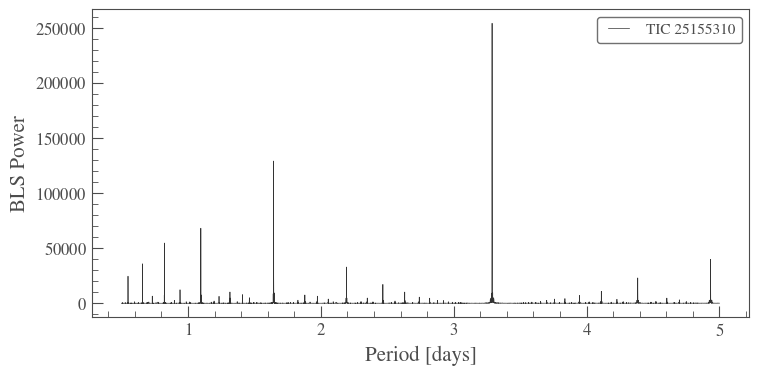

In [6]:
bls.plot()
plt.xlabel("Period [days]")
plt.ylabel("BLS Power")
plt.show()

The Box Least Squares (BLS) periodogram was used to search for periodic transit signals. The highest peak corresponds to an orbital period of approximately 3.289 days.

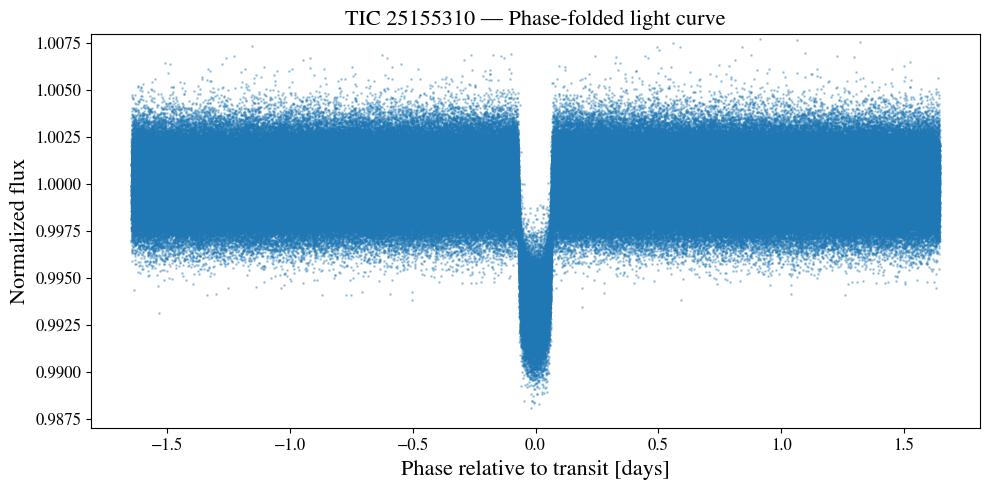

In [7]:
# Phase-fold the light curve using the BLS-derived period

folded = lc_clean.fold(
    period=period,
    epoch_time=t0
)

plt.figure(figsize=(10, 5))

plt.scatter(
    folded.phase.value,
    folded.flux.value,
    s=1,
    alpha=0.3
)

plt.xlabel(r"Phase relative to transit [days]", fontsize=16)
plt.ylabel(r"Normalized flux", fontsize=16)
plt.title(r"TIC 25155310 — Phase-folded light curve", fontsize=16)

plt.ylim(0.987, 1.008)
plt.tick_params(labelsize=12)
plt.tight_layout()
plt.show()

## Phase-folded light curve

##### The light curve is phase-folded using the period identified by the BLS periodogram. This places observations from different orbital cycles on the same phase axis, allowing the transit signal to be examined more clearly.

In [8]:
# Select data around the transit for modeling and visualization

fit_mask = np.abs(folded.phase.value) < 0.1
plot_mask = np.abs(folded.phase.value) < 0.5

phase_fit = folded.phase.value[fit_mask]
flux_fit = folded.flux.value[fit_mask]
flux_err_fit = folded.flux_err.value[fit_mask]

print("Points used for BATMAN fit:", len(phase_fit))

Points used for BATMAN fit: 41233


The transit is modeled using the `batman` package. The model assumes a circular orbit ($e=0$) and uses a quadratic limb-darkening law with fixed coefficients. The fitted parameters are the transit epoch, planet-to-star radius ratio, scaled semi-major axis, and orbital inclination.

In [9]:
# Defining the BATMAN transit model

def transit_model(phase, phase0, rp, a, inc):
    
    params = batman.TransitParams()
    params.t0 = phase0
    params.per = period
    params.rp = rp
    params.a = a
    params.inc = inc
    params.ecc = 0
    params.w = 90
    params.u = [0.3, 0.2]
    params.limb_dark = "quadratic"
    
    m = batman.TransitModel(params, phase)
    return m.light_curve(params)

In [10]:
# Obtaining initial transit parameters using a least-squares fit

p0 = [0.0, 0.1, 8.0, 89.0]

popt, pcov = curve_fit(
    transit_model,
    phase_fit,
    flux_fit,
    p0=p0
)

phase0_obs = popt[0]
rp_obs = popt[1]
a_obs = popt[2]
inc_obs = popt[3]

phase0_obs_er = np.sqrt(pcov[0][0])
rp_obs_er = np.sqrt(pcov[1][1])
a_obs_er = np.sqrt(pcov[2][2])
inc_obs_er = np.sqrt(pcov[3][3])

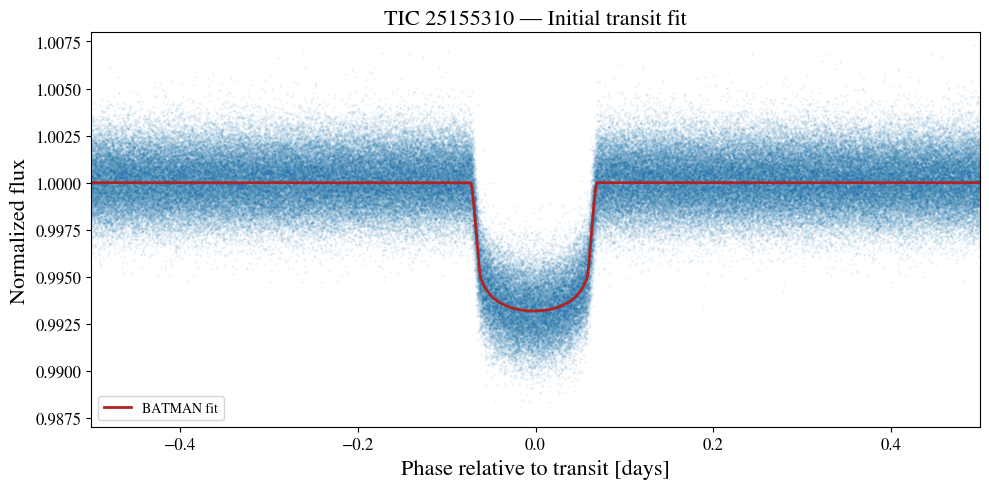

In [11]:
# Plot the initial BATMAN fit

best_fit = transit_model(
    folded.phase.value[plot_mask],
    *popt
)

plt.figure(figsize=(10, 5))

plt.scatter(
    folded.phase.value,
    folded.flux.value,
    s=1,
    alpha=0.05
)

plt.plot(
    folded.phase.value[plot_mask],
    best_fit,
    color="firebrick",
    lw=2,
    label="BATMAN fit"
)

plt.xlabel(r"Phase relative to transit [days]", fontsize=16)
plt.ylabel(r"Normalized flux", fontsize=16)
plt.title(r"TIC 25155310 — Initial transit fit", fontsize=16)

plt.xlim(-0.5, 0.5)
plt.ylim(0.987, 1.008)
plt.tick_params(labelsize=12)
plt.legend(loc = 'lower left')
plt.tight_layout()
plt.show()

In [12]:
# Setting up the BATMAN model for MCMC 

params = batman.TransitParams()

params.t0 = phase0_obs
params.per = period
params.rp = rp_obs
params.a = a_obs
params.inc = inc_obs
params.ecc = 0
params.w = 90
params.u = [0.3, 0.2]
params.limb_dark = "quadratic"

m = batman.TransitModel(params, phase_fit)

def transit_model_mcmc(theta):
    phase0, rp, a, inc = theta

    params.t0 = phase0
    params.rp = rp
    params.a = a
    params.inc = inc

    return m.light_curve(params)


# Defining the likelihood function
def log_likelihood(theta, flux, flux_err):
    model = transit_model_mcmc(theta)
    sigma2 = flux_err**2

    return -0.5 * np.sum(
        (flux - model)**2 / sigma2 + np.log(sigma2)
    )

#  Defining priors on the transit parameters
def log_prior(theta):
    phase0, rp, a, inc = theta
    
    if -0.01 < phase0 < 0.01 and 0.001 < rp < 0.3 and 2 < a < 25 and 80 < inc < 90:
        return 0.0  # flat prior
    return -np.inf

# Defining the posterior probability
def log_probability(theta, flux, flux_err):
    lp = log_prior(theta)

    if not np.isfinite(lp):
        return -np.inf

    return lp + log_likelihood(theta, flux, flux_err)

The MCMC sampler is initialized using the parameters obtained from the initial least-squares fit using. The walkers are distributed in a small region around this solution.

In [13]:
# Set up the MCMC sampler

ndim = 4
nwalkers = 32

initial = popt

pos = initial + 1e-3 * np.random.randn(nwalkers, ndim)

In [14]:
# Running the MCMC sampler

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(flux_fit, flux_err_fit)
)

sampler.run_mcmc(pos, 20000, progress=True)

100%|██████████████████████████████████████████████████████████████████████████| 20000/20000 [1:11:19<00:00,  4.67it/s]


State([[-1.93460789e-03  7.74528125e-02  7.65818530e+00  8.78003152e+01]
 [-1.85028724e-03  7.70692821e-02  7.83332405e+00  8.85220034e+01]
 [-1.84162064e-03  7.72142202e-02  7.76407977e+00  8.82307427e+01]
 [-1.84791810e-03  7.73964076e-02  7.74203451e+00  8.81098171e+01]
 [-1.91772410e-03  7.74965703e-02  7.58577035e+00  8.75641326e+01]
 [-1.84884189e-03  7.73445892e-02  7.72187075e+00  8.80224119e+01]
 [-1.90710917e-03  7.70919678e-02  7.85541953e+00  8.86141600e+01]
 [-1.80832230e-03  7.74204712e-02  7.66607450e+00  8.78534785e+01]
 [-1.92331195e-03  7.72530213e-02  7.75906749e+00  8.81782245e+01]
 [-1.86393349e-03  7.74974660e-02  7.66791816e+00  8.78326418e+01]
 [-1.88732638e-03  7.74452003e-02  7.67206116e+00  8.78635576e+01]
 [-1.80835563e-03  7.73213837e-02  7.73041675e+00  8.80860524e+01]
 [-1.85488274e-03  7.71288953e-02  7.81266543e+00  8.83863770e+01]
 [-1.87256319e-03  7.73146734e-02  7.75576340e+00  8.81950838e+01]
 [-1.85125186e-03  7.70836923e-02  7.85519881e+00  8.860

The MCMC sampler was run for 10,000 steps using 32 walkers. The walkers were initialized around the least-squares solution, and the posterior distribution was sampled using the likelihood and uniform priors defined above.

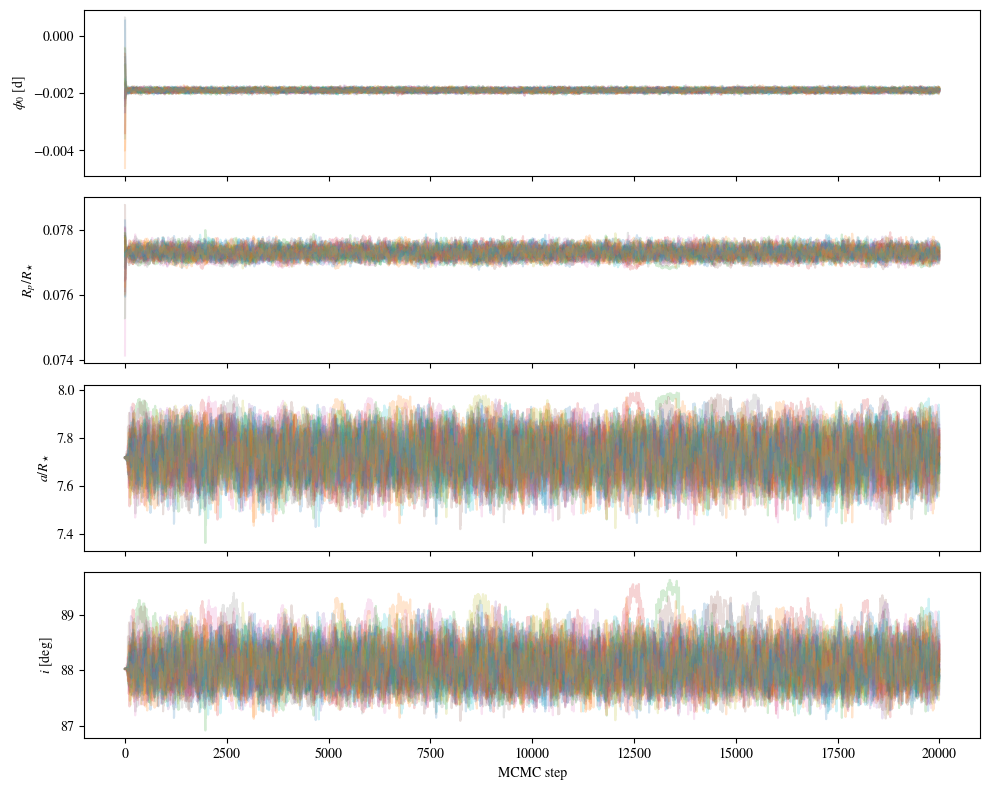

In [15]:
# Inspecting the MCMC chains

chain = sampler.get_chain()

fig, axes = plt.subplots(ndim, figsize=(10, 8), sharex=True)

labels = [r"$\phi_0$ [d]", r"$R_p/R_\star$", r"$a/R_\star$", r"$i$ [deg]"]

for i in range(ndim):
    axes[i].plot(chain[:, :, i], alpha=0.2)
    axes[i].set_ylabel(labels[i])

axes[-1].set_xlabel("MCMC step")
plt.tight_layout()
plt.show()

In [16]:
# Discarding the first 1000 steps as burn-in

samples = sampler.get_chain(discard=2000, flat=True)

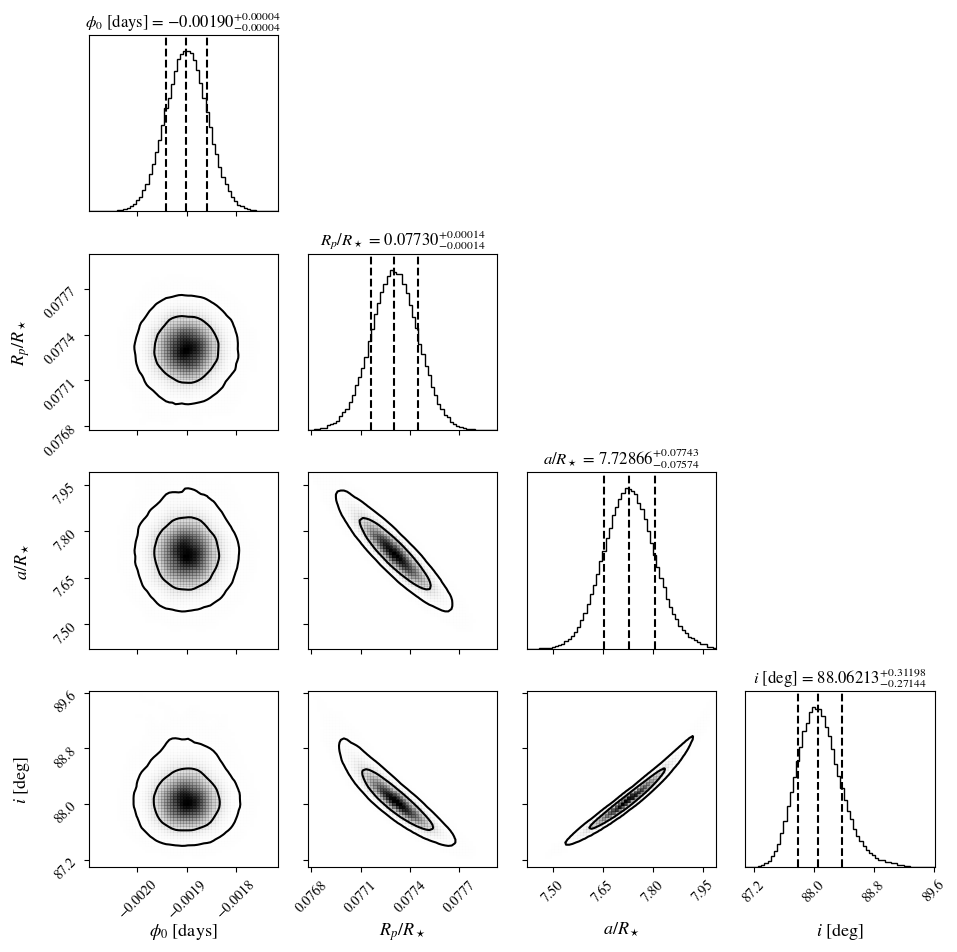

In [17]:
# Corner plot showing posterior probability distributions, probability histograms, and the parameter values

import corner

labels = [
    r"$\phi_0$ [days]",
    r"$R_p/R_\star$",
    r"$a/R_\star$",
    r"$i$ [deg]"
]

fig = corner.corner(
    samples,
    labels=labels,
    bins=60,
    smooth=1.0,
    color="black",
    show_titles=True,
    title_fmt=".5f",
    title_kwargs={"fontsize": 12},
    label_kwargs={"fontsize": 13},
    quantiles=[0.16, 0.50, 0.84],
    levels=(0.68, 0.95),
    plot_datapoints=False,
    fill_contours=False,
    hist_kwargs={"density": True},
    max_n_ticks=4
)

plt.tight_layout()
plt.show()

In [18]:
# Converting to physical units

phase0_mcmc = np.percentile(samples[:,0], [16, 50, 84])
rp_mcmc = np.percentile(samples[:,1], [16, 50, 84])
a_mcmc  = np.percentile(samples[:,2], [16, 50, 84])
inc_mcmc = np.percentile(samples[:,3], [16, 50, 84])

R_sol = 695700000
R_jup = 69886000
AU = 149597870700

R_p = 1.27 * R_sol * rp_mcmc[1] / R_jup
a_au = a_mcmc[1] * R_sol / AU
print(f"The planet radius is {R_p:.3f} of Jupiter's radius")
print(f"The orbital radius is {a_au:.3f} AU")

The planet radius is 0.977 of Jupiter's radius
The orbital radius is 0.036 AU


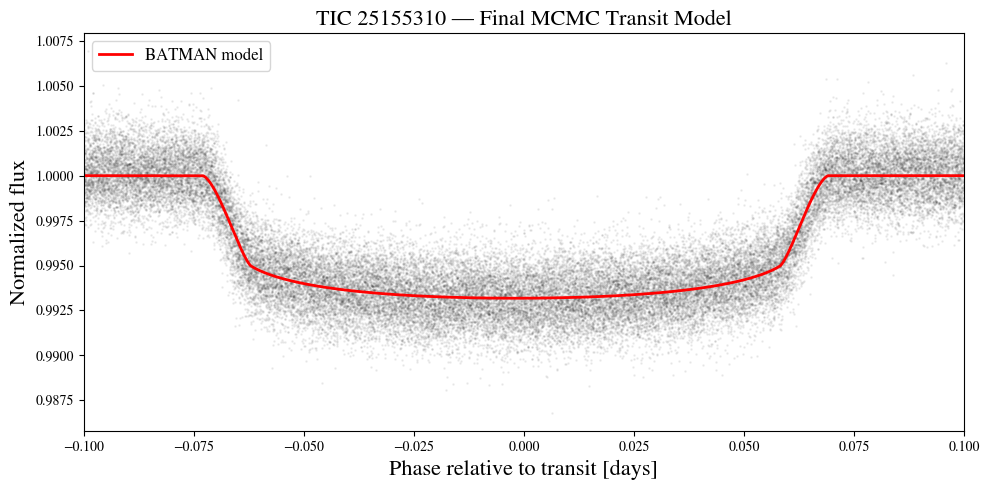

In [20]:
# Final transit model using the median MCMC parameters

theta_mcmc = [
    phase0_mcmc[1],
    rp_mcmc[1],
    a_mcmc[1],
    inc_mcmc[1]
]

model_flux = transit_model(phase_fit, *theta_mcmc)

plt.figure(figsize=(10, 5))

plt.scatter(phase_fit, flux_fit, s=1, alpha=0.05, color = 'black')

plt.plot(phase_fit, model_flux, lw=2, color = 'red', label="BATMAN model")
plt.title("TIC 25155310 — Final MCMC Transit Model", fontsize=16)
plt.xlabel("Phase relative to transit [days]", fontsize=16)
plt.ylabel("Normalized flux", fontsize=16)
plt.xlim(-0.10, 0.10)
plt.legend(fontsize = 12)
plt.tight_layout()
plt.savefig("TIC 25155310 — Final MCMC Transit Model.pdf")
plt.show()

## Results and Conclusion

The transit parameters and their uncertainties were estimated using an MCMC analysis of the phase-folded TESS light curve. The resulting posterior distributions give

$$
\frac{R_p}{R_\star} =
(7.73\pm 0.01)\times10^{-2},
$$

$$
\frac{a}{R_\star} =
7.73\pm 0.08,
$$

and

$$
i = 88.05^{+0.31}_{-0.27}\ \mathrm{deg}.
$$

The orbital period obtained from the BLS period search is

$$
P = 3.289\ \mathrm{days}.
$$

Using the stellar radius of

$$
R_\star = 1.27^{+0.10}_{-0.05}\ R_\odot,
$$

the estimated planet radius is approximately

$$
R_p \approx 0.98\ R_J,
$$

while the semi-major axis is approximately

$$
a \approx 0.036\ \mathrm{AU}.
$$

The resulting parameters are consistent with the known properties of TIC 25155310 b (WASP-126 b), a hot-Jupiter-type exoplanet.

This project demonstrates a basic workflow for exoplanet transit analysis using TESS data, from light-curve extraction and period determination to transit modeling and MCMC parameter estimation.